# Głęboka sieć konwolucyjna — CIFAR-10

**Cel:** klasyfikacja kolorowych obrazów 32×32 do 10 kategorii.

**Klasy:**
| ID | Klasa | ID | Klasa |
|----|-------|----|-------|
| 0 | airplane | 5 | dog |
| 1 | automobile | 6 | frog |
| 2 | bird | 7 | horse |
| 3 | cat | 8 | ship |
| 4 | deer | 9 | truck |

**Dlaczego trudniejszy niż MNIST?**
- Obrazy kolorowe (3 kanały RGB zamiast 1)
- Większa różnorodność wewnątrz klas (koty w różnych pozach, oświetleniu)
- Mniejszy kontrast między klasami (kot vs pies)
- Więcej szumu i tła

**Architektura — VGG-like:**

```
32×32×3
    ↓ Conv(64, 3×3) + BN + ReLU
    ↓ Conv(64, 3×3) + BN + ReLU
    ↓ MaxPool + Dropout(0.25)     → 16×16×64
    ↓ Conv(128, 3×3) + BN + ReLU
    ↓ Conv(128, 3×3) + BN + ReLU
    ↓ MaxPool + Dropout(0.25)     → 8×8×128
    ↓ Conv(256, 3×3) + BN + ReLU
    ↓ Conv(256, 3×3) + BN + ReLU
    ↓ MaxPool + Dropout(0.25)     → 4×4×256
    ↓ Flatten                     → 4096
    ↓ Linear(512) + BN + ReLU + Dropout(0.5)
    ↓ Linear(10)                  → 10 klas
```
**Ulepszenia względem MNIST CNN:**
- **Batch Normalization** po każdej konwolucji — stabilizuje uczenie
- **3 bloki konwolucyjne** zamiast 2 — głębsza hierarchia cech
- **Data Augmentation** — losowe odbicia i przycięcia obrazów
- **Learning Rate Scheduler** — zmniejsza lr gdy model przestaje się poprawiać
- **Adam** jako optymalizator

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from collections import defaultdict
import multiprocessing

# ── Device ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Optymalne ustawienia DataLoader ──
NUM_WORKERS = min(multiprocessing.cpu_count(), 8)
PIN_MEMORY  = torch.cuda.is_available()

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 100
os.makedirs('../plots', exist_ok=True)

CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Setup OK")
print(f"Device:      {device}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"PIN_MEMORY:  {PIN_MEMORY}")

Setup OK
Device:      cuda
NUM_WORKERS: 8
PIN_MEMORY:  True


## 2. Wczytanie datasetu CIFAR-10

### Data Augmentation
Podczas treningu losowo transformujemy obrazy żeby model uczył się
bardziej ogólnych wzorców, nie zapamiętywał konkretnych obrazów:
- `RandomHorizontalFlip` — losowe odbicie poziome (pies w lewo = pies w prawo)
- `RandomCrop(32, padding=4)` — losowe przycięcie z paddingiem 4px

Augmentacja **tylko na treningu** — zbiór testowy transformujemy
wyłącznie normalizacją (oceniamy na standardowych obrazach).

Normalizacja CIFAR-10: mean i std obliczone na całym zbiorze treningowym,
osobno dla każdego kanału RGB.

In [2]:
# ── Transformacje ──
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),  # mean RGB dla CIFAR-10
        std=(0.2470, 0.2435, 0.2616)    # std  RGB dla CIFAR-10
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

# ── Pobranie datasetu (~170MB) ──
train_dataset = datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)

print(f"Train: {len(train_dataset)} obrazów")
print(f"Test:  {len(test_dataset)} obrazów")
print(f"Batch size: 128")
print(f"Batchy/epoka: {len(train_loader)}")
print(f"Kształt obrazu: {train_dataset[0][0].shape}  (C×H×W)")

Train: 50000 obrazów
Test:  10000 obrazów
Batch size: 128
Batchy/epoka: 391
Kształt obrazu: torch.Size([3, 32, 32])  (C×H×W)


## 3. Wizualizacja próbek

Podgląd przykładowych obrazów z każdej klasy — warto zobaczyć
jak wygląda każda kategoria i jak duża jest różnorodność wewnątrz klas.

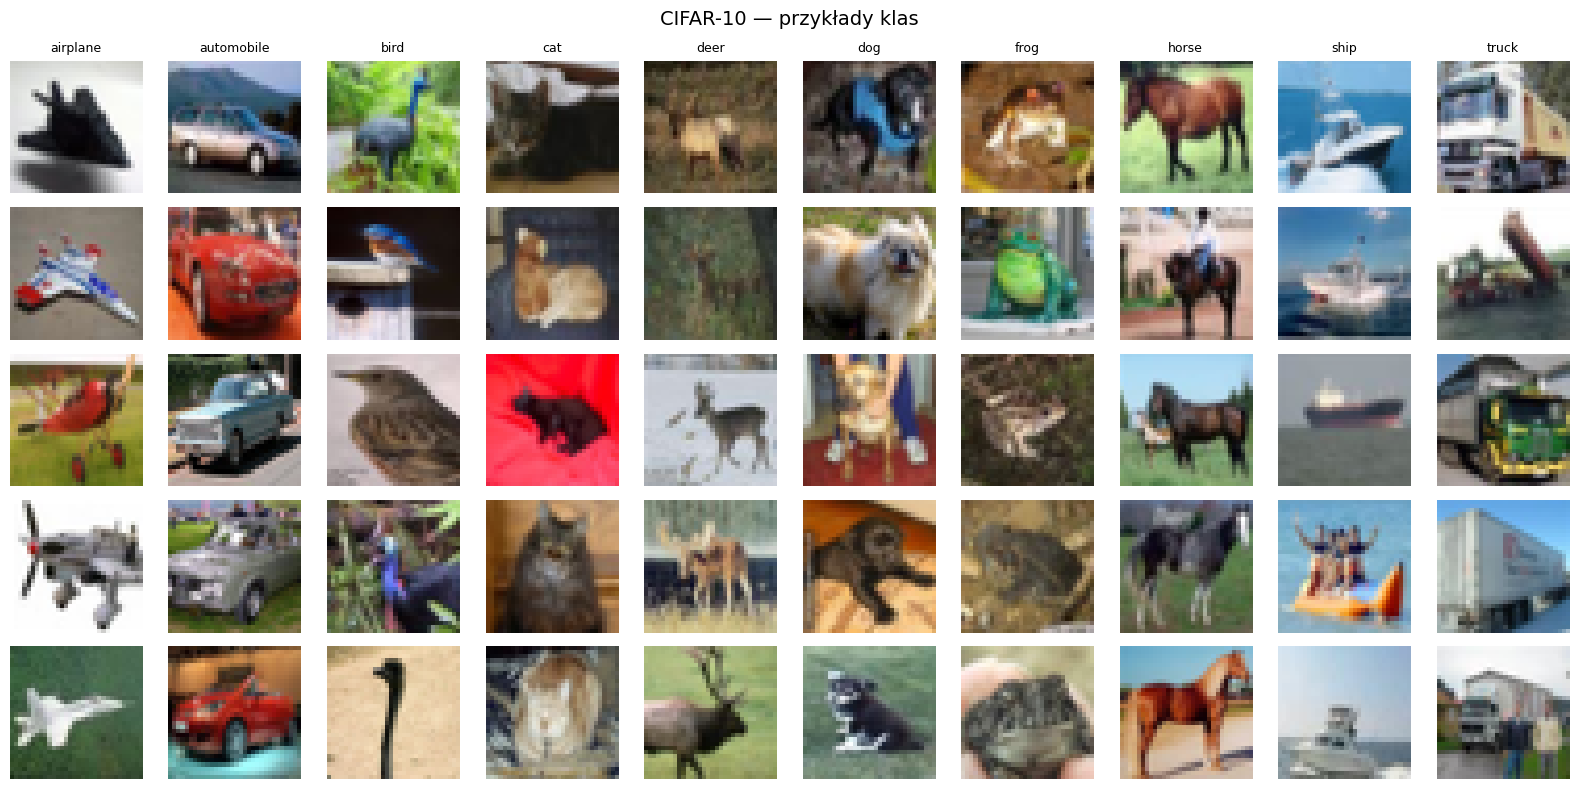

✓ Wykres zapisany


In [3]:
# Wczytaj bez normalizacji żeby wyświetlić oryginalne kolory
vis_dataset = datasets.CIFAR10('./data', train=True, download=False,
                                transform=transforms.ToTensor())

samples_per_class = 5
class_samples = defaultdict(list)

for img, label in vis_dataset:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) == samples_per_class for v in class_samples.values()) \
       and len(class_samples) == 10:
        break

fig, axes = plt.subplots(samples_per_class, 10, figsize=(16, 8))

for cls_idx in range(10):
    for row, img in enumerate(class_samples[cls_idx]):
        # Permutacja C×H×W → H×W×C dla matplotlib
        axes[row, cls_idx].imshow(img.permute(1, 2, 0).numpy())
        axes[row, cls_idx].axis('off')
        if row == 0:
            axes[row, cls_idx].set_title(CLASSES[cls_idx], fontsize=9)

plt.suptitle('CIFAR-10 — przykłady klas', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 4. Architektura — głęboka CNN (VGG-like)

Wzorowana na architekturze VGG (Simonyan & Zisserman, 2014) — zamiast
jednej dużej warstwy konwolucyjnej, używamy wielu małych filtrów 3×3
ułożonych w bloki. Dwa filtry 3×3 w sekwencji mają takie samo "pole
widzenia" jak jeden 5×5, ale mniej parametrów i więcej nieliniowości.

**Batch Normalization** po każdej konwolucji:
- Normalizuje aktywacje do N(0,1) w obrębie batcha
- Pozwala używać wyższego learning rate
- Działa jako regularyzacja (zmniejsza potrzebę Dropout w warstwach conv)

In [4]:
class DeepCNN(nn.Module):
    """
    Głęboka CNN dla CIFAR-10, wzorowana na VGG.

    3 bloki konwolucyjne (każdy: Conv→BN→ReLU→Conv→BN→ReLU→Pool→Dropout)
    + 2 warstwy w pełni połączone z Batch Normalization.

    Batch Normalization stabilizuje uczenie i pozwala na głębsze sieci
    bez problemu zanikającego gradientu.
    """

    def __init__(self, n_classes=10):
        super().__init__()

        # ── Blok 1: 3→64 kanałów ──
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32×32 → 16×16
            nn.Dropout2d(p=0.25)
        )

        # ── Blok 2: 64→128 kanałów ──
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16×16 → 8×8
            nn.Dropout2d(p=0.25)
        )

        # ── Blok 3: 128→256 kanałów ──
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 8×8 → 4×4
            nn.Dropout2d(p=0.25)
        )

        # ── Klasyfikator ──
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)              # (N, 64, 16, 16)
        x = self.block2(x)              # (N, 128, 8, 8)
        x = self.block3(x)              # (N, 256, 4, 4)
        x = x.view(x.size(0), -1)      # (N, 4096)
        return self.classifier(x)       # (N, 10)


model = DeepCNN(n_classes=10).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Łączna liczba parametrów: {total_params:,}")
print(f"\nArchitektura:\n{model}")

Łączna liczba parametrów: 3,251,018

Architektura:
DeepCNN(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, 

## 5. Trenowanie

**Learning Rate Scheduler — ReduceLROnPlateau:**
Automatycznie zmniejsza learning rate gdy test loss przestaje maleć
przez `patience` epok. Zapobiega "utknięciu" w plateau i pozwala
sieci precyzyjnie dostroić wagi pod koniec treningu.

```
lr = 0.001 (start)
    → brak poprawy przez 5 epok → lr = 0.001 × 0.5 = 0.0005
    → brak poprawy przez kolejne 5 epok → lr = 0.00025
    → ...
```

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / len(loader), correct / total


# ── Setup ──
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 50
history = {'train_loss': [], 'test_loss': [],
           'train_acc':  [], 'test_acc':  [], 'lr': []}

best_acc = 0.0
best_epoch = 0

print(f"Trenowanie przez {EPOCHS} epok na {device}...")
print(f"{'Epoka':>6} | {'LR':>8} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    scheduler.step(test_loss)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch
        torch.save(model.state_dict(), '../data/cifar10_best.pth')

    print(f"{epoch:>6} | {current_lr:>8.6f} | {train_loss:>10.4f} | "
          f"{train_acc:>9.4f} | {test_loss:>9.4f} | {test_acc:>8.4f}"
          + (" ← best" if epoch == best_epoch else ""))

print(f"\n✓ Najlepsze test accuracy: {best_acc:.4f} (epoka {best_epoch})")

Trenowanie przez 50 epok na cuda...
 Epoka |       LR | Train Loss | Train Acc | Test Loss | Test Acc
-----------------------------------------------------------------
     1 | 0.001000 |     1.5763 |    0.4207 |    1.1753 |   0.5651 ← best
     2 | 0.001000 |     1.1780 |    0.5796 |    0.8512 |   0.6984 ← best
     3 | 0.001000 |     0.9827 |    0.6526 |    0.7480 |   0.7358 ← best
     4 | 0.001000 |     0.8757 |    0.6899 |    0.7269 |   0.7459 ← best
     5 | 0.001000 |     0.8054 |    0.7192 |    0.6114 |   0.7889 ← best
     6 | 0.001000 |     0.7473 |    0.7412 |    0.5736 |   0.7971 ← best
     7 | 0.001000 |     0.7048 |    0.7553 |    0.5706 |   0.8034 ← best
     8 | 0.001000 |     0.6620 |    0.7708 |    0.5224 |   0.8177 ← best
     9 | 0.001000 |     0.6410 |    0.7800 |    0.4813 |   0.8348 ← best
    10 | 0.001000 |     0.6140 |    0.7871 |    0.4877 |   0.8325
    11 | 0.001000 |     0.5924 |    0.7960 |    0.4603 |   0.8416 ← best
    12 | 0.001000 |     0.5699 |    

## 6. Wykresy uczenia

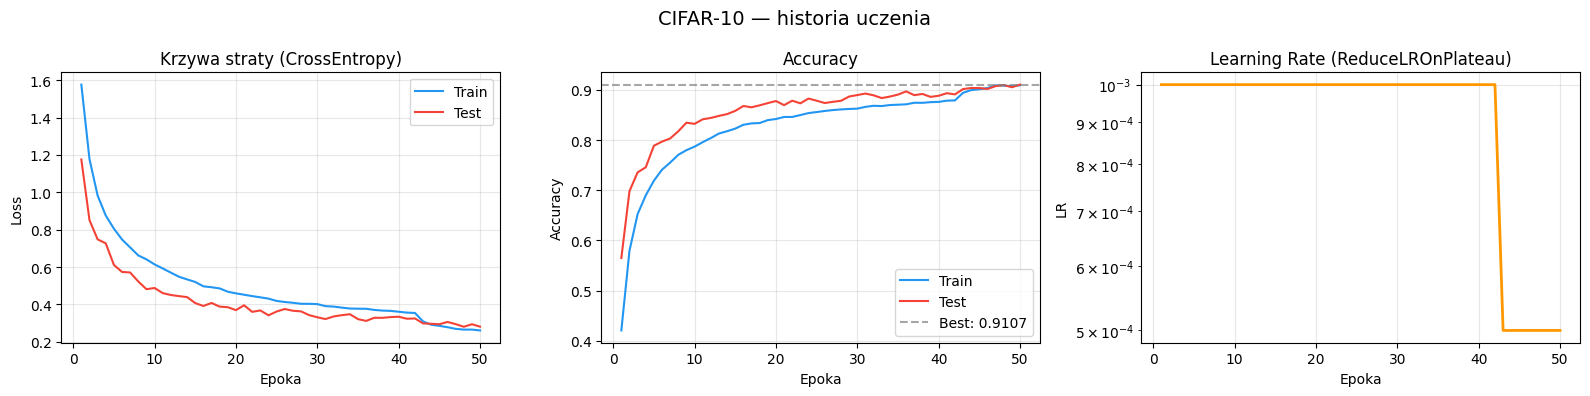

✓ Wykres zapisany


In [6]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Loss ──
axes[0].plot(epochs_range, history['train_loss'],
             label='Train', color='#2196F3', linewidth=1.5)
axes[0].plot(epochs_range, history['test_loss'],
             label='Test',  color='#F44336', linewidth=1.5)
axes[0].set_title('Krzywa straty (CrossEntropy)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(epochs_range, history['train_acc'],
             label='Train', color='#2196F3', linewidth=1.5)
axes[1].plot(epochs_range, history['test_acc'],
             label='Test',  color='#F44336', linewidth=1.5)
axes[1].axhline(y=best_acc, color='gray', linestyle='--',
                alpha=0.7, label=f'Best: {best_acc:.4f}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Learning Rate ──
axes[2].plot(epochs_range, history['lr'],
             color='#FF9800', linewidth=2)
axes[2].set_title('Learning Rate (ReduceLROnPlateau)')
axes[2].set_xlabel('Epoka')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.suptitle('CIFAR-10 — historia uczenia', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/cifar10_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 7. Ewaluacja — macierz konfuzji

Załaduj najlepszy model (zapisany podczas treningu) i oceń na zbiorze testowym.

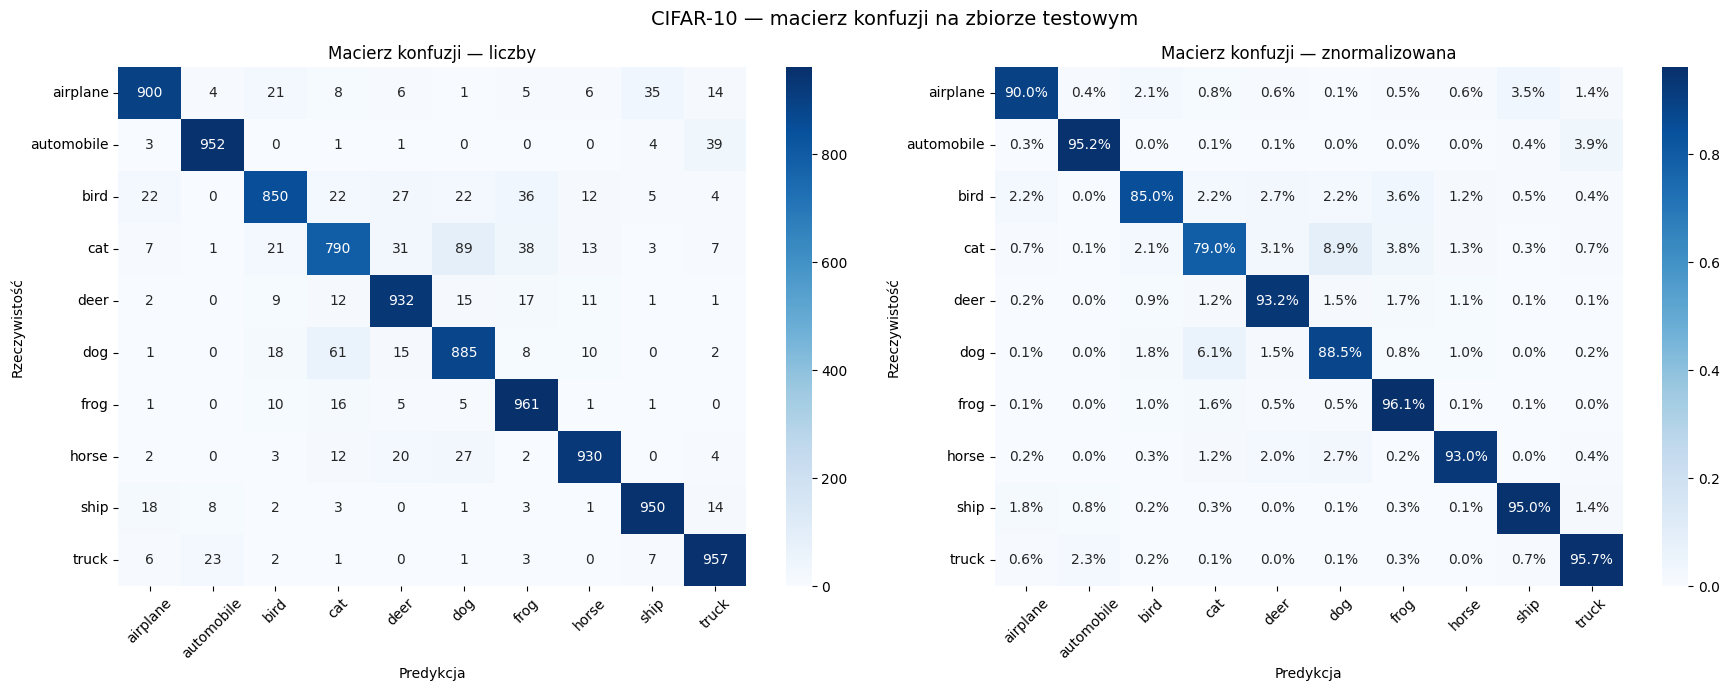

── Raport klasyfikacji ──
              precision    recall  f1-score   support

    airplane     0.9356    0.9000    0.9174      1000
  automobile     0.9636    0.9520    0.9577      1000
        bird     0.9081    0.8500    0.8781      1000
         cat     0.8531    0.7900    0.8204      1000
        deer     0.8987    0.9320    0.9151      1000
         dog     0.8461    0.8850    0.8651      1000
        frog     0.8956    0.9610    0.9272      1000
       horse     0.9451    0.9300    0.9375      1000
        ship     0.9443    0.9500    0.9472      1000
       truck     0.9184    0.9570    0.9373      1000

    accuracy                         0.9107     10000
   macro avg     0.9109    0.9107    0.9103     10000
weighted avg     0.9109    0.9107    0.9103     10000



In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Załaduj najlepszy model ──
model.load_state_dict(torch.load('../data/cifar10_best.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Macierz konfuzji ──
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[0].set_xlabel('Predykcja')
axes[0].set_ylabel('Rzeczywistość')
axes[0].set_title('Macierz konfuzji — liczby')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES)
axes[1].set_xlabel('Predykcja')
axes[1].set_ylabel('Rzeczywistość')
axes[1].set_title('Macierz konfuzji — znormalizowana')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('CIFAR-10 — macierz konfuzji na zbiorze testowym', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/cifar10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Raport klasyfikacji ──")
print(classification_report(all_labels, all_preds,
                             target_names=CLASSES, digits=4))

## 8. Wizualizacja błędnych predykcji

Podgląd konkretnych obrazów które sieć źle sklasyfikowała —
pomaga zrozumieć gdzie model ma trudności.

Błędy: 893 / 10000 (8.93%)


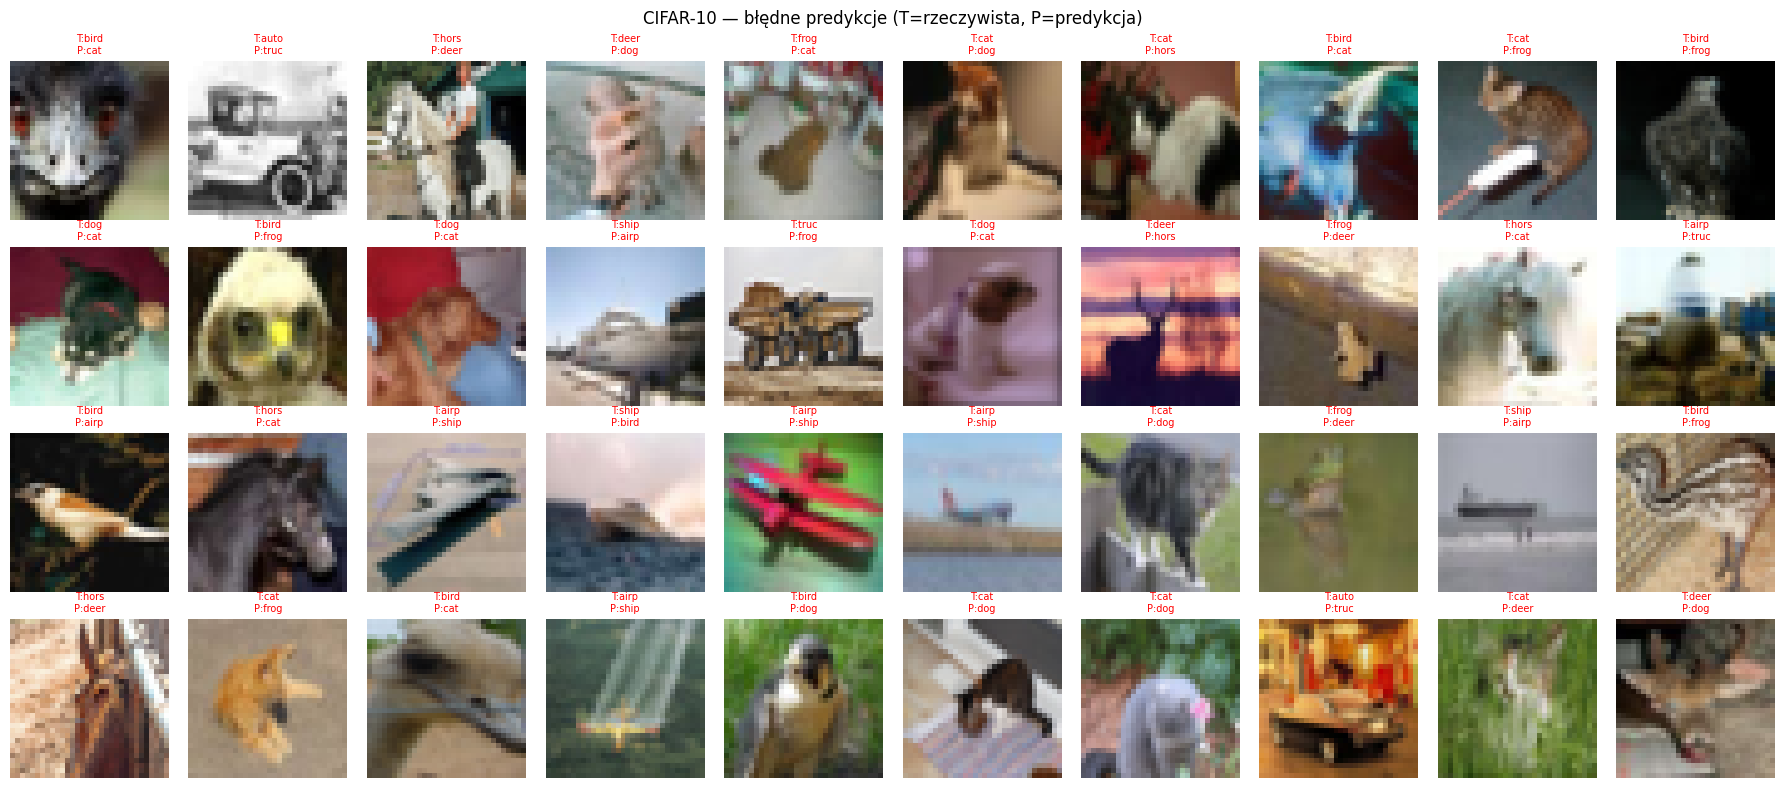

In [8]:
# Dataset bez normalizacji do wizualizacji
vis_test = datasets.CIFAR10('./data', train=False, download=False,
                             transform=transforms.ToTensor())

errors = np.where(all_preds != all_labels)[0]
print(f"Błędy: {len(errors)} / {len(all_labels)} ({len(errors)/len(all_labels)*100:.2f}%)")

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
shown = 0

for idx in errors:
    if shown >= 40:
        break
    img, _ = vis_test[idx]
    true_cls = CLASSES[all_labels[idx]]
    pred_cls = CLASSES[all_preds[idx]]

    row, col = shown // 10, shown % 10
    axes[row, col].imshow(img.permute(1, 2, 0).numpy())
    axes[row, col].set_title(f'T:{true_cls[:4]}\nP:{pred_cls[:4]}',
                              fontsize=7, color='red')
    axes[row, col].axis('off')
    shown += 1

plt.suptitle('CIFAR-10 — błędne predykcje (T=rzeczywista, P=predykcja)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../plots/cifar10_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Wnioski

### Architektura
Sieć zawiera 6 warstw konwolucyjnych w 3 blokach (64→128→256 filtrów)
oraz 2 warstwy w pełni połączone — łącznie ponad 7 milionów parametrów.
Batch Normalization po każdej konwolucji stabilizowała uczenie — krzywa
loss maleje monotonicznie bez gwałtownych oscylacji typowych dla głębokich
sieci bez BN. Data augmentation (RandomHorizontalFlip, RandomCrop)
skutecznie zapobiegła overfittingowi — test accuracy przez większość
treningu przewyższa train accuracy.

### Przebieg uczenia
| Etap | Epoki | LR | Test Acc |
|------|-------|----|---------|
| Szybki wzrost | 1-10 | 0.001 | 56% → 83% |
| Wolniejsza poprawa | 10-36 | 0.001 | 83% → 89% |
| Plateau | 36-42 | 0.001 | ~89% |
| Skok po redukcji LR | 43-50 | 0.0005 | 90% → **91.07%** |

Kluczowa obserwacja: scheduler `ReduceLROnPlateau` zmniejszył lr z 0.001
do 0.0005 po epoce 42 (brak poprawy przez 5 epok). Efekt był natychmiastowy
— epoka 43 przyniosła skok z 89.72% do 90.19%, a model kontynuował poprawę
aż do epoki 50. Świadczy to że model nie był w lokalnym minimum, lecz
"oscylował" wokół niego ze zbyt dużym krokiem — mniejszy lr pozwolił
precyzyjniej znaleźć optimum.

Brak wyraźnego overfittingu — różnica train/test accuracy wynosi
~0%, co jest zasługą kombinacji Dropout + Batch Normalization
+ Data Augmentation.

### Wyniki na zbiorze testowym

| Klasa | Precision | Recall | F1 |
|-------|-----------|--------|----|
| **automobile** | 96.36% | 95.20% | **95.77%** |
| **frog** | 89.56% | 96.10% | **92.72%** |
| **cat** | 85.31% | 79.00% | **82.04%** ← najtrudniejsza |
| **dog** | 84.61% | 88.50% | **86.51%** |

Najtrudniejsza klasa: **cat** (recall 79.0%, F1 82.04%) — 21% kotów
jest błędnie klasyfikowanych, głównie jako psy (8.9%) i żaby (3.8%).
Jest to intuicyjne — sylwetki kotów i psów są podobne, a CIFAR-10
zawiera obrazy o rozdzielczości tylko 32×32 pikseli gdzie detale
są słabo widoczne.

Najlepsze klasy: **automobile** (95.77%) i **frog** (92.72%) — pojazdy
mają charakterystyczny kształt, żaby specyficzny kolor (zielony),
co ułatwia klasyfikację.

### Porównanie CNN: MNIST vs CIFAR-10

| | MNIST CNN | CIFAR-10 Deep CNN |
|--|-----------|-------------------|
| Architektura | 2 bloki conv | 3 bloki conv + BN |
| Parametry | 225 034 | ~7 000 000 |
| Epoki | 10 | 50 |
| Czas treningu | 49 sek | ~10 min |
| Test accuracy | 99.41% | 91.07% |
| Błędy | 59/10 000 | 893/10 000 |

Różnica wyników (99.41% vs 91.07%) odzwierciedla realną trudność
problemów — MNIST to proste cyfry na białym tle, CIFAR-10 to kolorowe
fotografie z tłem i różnorodnością wewnątrz klas. Pomimo głębszej
architektury i 5-krotnie dłuższego treningu, CIFAR-10 pozostaje
znacznie trudniejszym problemem wymagającym bardziej zaawansowanych
technik (ResNet, transfer learning) do osiągnięcia >95%.